# SMS Spam Classification Project
**Course:** Machine Learning
**Model:** Optimized Multinomial Naive Bayes

### Student Details:
* **Student 1:** Ravid.b, id: 3783
* **Student 2:** Sagi.n, id: 8835
* **Student 3:** Gil.s, id: 2797

---
### Problem & Dataset Overview
**The Problem:** Classification of SMS messages into two categories: **Spam** (unsolicited) and **Ham** (legitimate). This is a supervised binary classification task.

**The Dataset:** The dataset contains approximately 5,574 labeled SMS messages.
* **Target variable:** `label` (1 for Spam, 0 for Ham).
* **Features:** Raw text undergoing extensive preprocessing and numerical transformation via TF-IDF and Count Vectorizers.

---

### Project Structure
The project logic is modularized inside the `src` directory to maintain clean and professional code:
1. **`data_loader.py`:** Handles dataset paths and loading logic (including label encoding to numerical values).
2. **`preprocessing.py`:** Advanced text cleaning using Regex (URL and punctuation removal), stop-words filtering, and vectorization pipelines.
3. **`model_logic.py`:** Implementation of the Naive Bayes model, Alpha parameter optimization using Grid Search, training, and prediction logic.
4. **`eval_plots.py`:** Calculation of performance metrics (Precision, Recall, F1) and generation of visualizations (Confusion Matrix, ROC Curve) and model explainability (Top Features).

---

### AI Usage & Prompt Documentation
To complete this project, we collaborated with **Gemini** and **Claude** as technical assistants.
**The goals of using AI were:**
1. Designing a modular code architecture (separating logic into `.py` files).
2. Optimizing text cleaning logic using complex Regex patterns.
3. Troubleshooting technical issues regarding GridSearchCV and feature engineering pipelines.
4. Implementing "Explainability" features to understand the weights assigned to specific keywords.

#### **Sample Prompts & Questions used:**
* **Architecture:** "How to restructure a flat Jupyter notebook into a professional project with separate .py files for data loading and model logic?"
* **Feature Engineering:** "Create a Python function that demonstrates the Feature Engineering process by showing raw text, cleaned text, and active features for specific rows."
* **Comparison:** "How to compare CountVectorizer(binary=True) vs TfidfVectorizer in a pandas DataFrame using 5-fold cross-validation?"
* **Debugging:** "How to fix 'KeyError: param_fit_prior' when displaying GridSearchCV results in a DataFrame?"
* **Visualization:** "Write a Matplotlib script to visualize the top 15 words with the highest log-probability for Spam and Ham classes in a Naive Bayes model."


# Part 1: Initialization & Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

# Importing the functions from src
from src.data_loader import load_datasets
from src.preprocessing import clean_text, vectorize_data
from src.model_logic import train_and_evaluate_model
from src.eval_plots import evaluate_full

print("Loading datasets...")
train_df, test_df = load_datasets()

#Preview of the data
print("Train Set Sample:")
display(train_df.head())
print("Test Set Sample:")
display(test_df.head())

Loading datasets...
Train Set Sample:


[nltk_data] Downloading package stopwords to C:\Users\Ravid
[nltk_data]     Barzily\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,label,text
1350,1,FREE2DAY sexy St George's Day pic of Jordan!Tx...
5544,0,Armand says get your ass over to epsilon
1168,0,Lol now I'm after that hot air balloon!
5551,0,"You know, wot people wear. T shirts, jumpers, ..."
5320,0,"Good morning, my Love ... I go to sleep now an..."


Test Set Sample:


,label,text
3690,0,You still coming tonight?
3527,0,"""HEY BABE! FAR 2 SPUN-OUT 2 SPK AT DA MO... DE..."
724,0,Ya even those cookies have jelly on them
3370,0,Sorry i've not gone to that place. I.ll do so ...
468,0,When are you going to ride your bike?


# Part 2: Text Preprocessing & Vectorization

In [2]:
print("1. Cleaning text data (This might take a few seconds)...")
# Applying the cleaning logic you built
train_df['cleaned_text'] = train_df['text'].apply(clean_text)
test_df['cleaned_text'] = test_df['text'].apply(clean_text)

print(train_df[['text', 'cleaned_text']].head())

print("2. Transforming text into binary feature vectors...")
# Using the binary=True CountVectorizer logic
X_train, X_test, vectorizer = vectorize_data(train_df['cleaned_text'], test_df['cleaned_text'])

# Defining our targets
y_train = train_df['label']
y_test = test_df['label']

print(f"\nPreprocessing Completed!")
print(f"Final feature matrix shape: {X_train.shape}")

1. Cleaning text data (This might take a few seconds)...
                                                   text  \
1350  FREE2DAY sexy St George's Day pic of Jordan!Tx...   
5544           Armand says get your ass over to epsilon   
1168            Lol now I'm after that hot air balloon!   
5551  You know, wot people wear. T shirts, jumpers, ...   
5320  Good morning, my Love ... I go to sleep now an...   

                                           cleaned_text  
1350  free2day sexy st george day pic jordan txt pic...  
5544                        armand says get ass epsilon  
1168                                lol hot air balloon  
5551  know wot people wear shirts jumpers hat belt k...  
5320  good morning love go sleep wish great day full...  
2. Transforming text into binary feature vectors...

Preprocessing Completed!
Final feature matrix shape: (4459, 5000)


# Part 3: Model Training & Hyperparameter Tuning

In [3]:
print("Initializing Grid Search CV for Multinomial Naive Bayes...\n")

# This will run the 5-fold cross-validation and find the best alpha
best_model, metrics, grid_search = train_and_evaluate_model(X_train, y_train, X_test, y_test)

Initializing Grid Search CV for Multinomial Naive Bayes...

Starting Custom Grid Search (CV=5)...
Optimization complete! Best params: {'alpha': 2.0, 'fit_prior': True}

----------------------------------------
Train Result (Optimized Model):
Accuracy:  0.9910
Precision: 0.9806
Recall:    0.9505
F1-Score:  0.9653
----------------------------------------
Test Result (Optimized Model):
Accuracy:  0.9821
Precision: 0.9434
Recall:    0.9317
F1-Score:  0.9375
----------------------------------------


# Part 4: Final Evaluation & Visualizations

Generating final evaluation results and explainability charts...
Evaluation Results
Accuracy:  0.9821
Precision: 0.9434
Recall:    0.9317
F1 Score:  0.9375
----------------------------------------
              precision    recall  f1-score   support

    Not Spam       0.99      0.99      0.99       954
        Spam       0.94      0.93      0.94       161

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



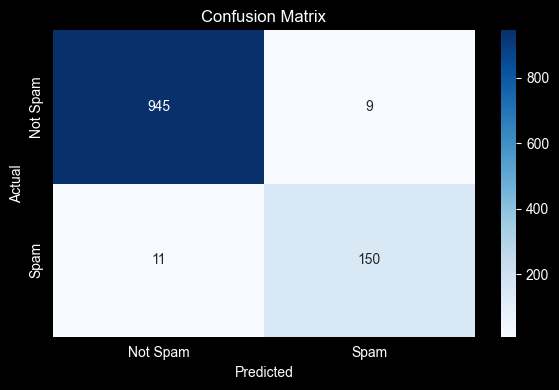

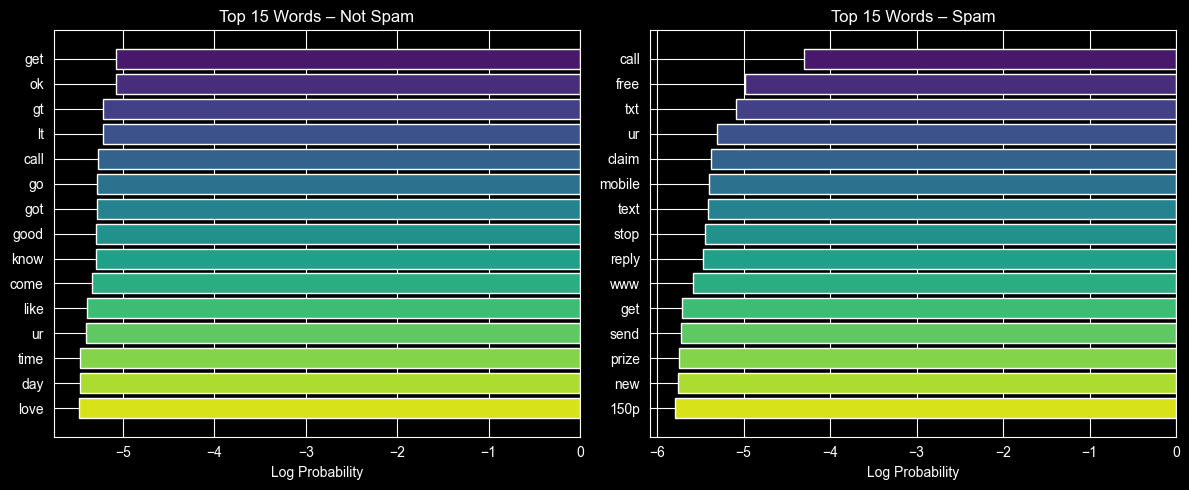

In [4]:
print("Generating final evaluation results and explainability charts...")

final_metrics, fig_cm, fig_feat = evaluate_full(best_model, vectorizer, X_test, y_test)

plt.show()

# Part 5: Model Prediction & Performance Evaluation (Test Set)

### Part 5.1: Feature Engineering Demonstration (Train & Test)

In [5]:
def showcase_fe(df, set_name, indices):
    print(f"--- Feature Engineering Showcase: {set_name} Set ---")
    for idx in indices:
        raw_text = df.iloc[idx]['text']
        cleaned = clean_text(raw_text)

        # Transform and find active features
        vectorized = vectorizer.transform([cleaned])
        active_features = [vectorizer.get_feature_names_out()[i] for i in vectorized.indices]

        print(f"Example Index {idx}:")
        print(f"  RAW: {raw_text[:100]}...")
        print(f"  CLEANED: {cleaned[:100]}...")
        print(f"  ACTIVE FEATURES: {active_features}")
        print("-" * 30)

# Show 2 examples from Train and 2 from Test
showcase_fe(train_df, "TRAIN", indices=[10, 20])
showcase_fe(test_df, "TEST", indices=[5, 15])

--- Feature Engineering Showcase: TRAIN Set ---
Example Index 10:
  RAW: Were somewhere on Fredericksburg...
  CLEANED: somewhere fredericksburg...
  ACTIVE FEATURES: ['fredericksburg', 'somewhere']
------------------------------
Example Index 20:
  RAW: I anything lor......
  CLEANED: anything lor...
  ACTIVE FEATURES: ['anything', 'lor']
------------------------------
--- Feature Engineering Showcase: TEST Set ---
Example Index 5:
  RAW: Daddy, shu shu is looking 4 u... U wan me 2 tell him u're not in singapore or wat?...
  CLEANED: daddy shu shu looking 4 u u wan 2 tell u singapore wat...
  ACTIVE FEATURES: ['daddy', 'looking', 'tell', 'wan', 'wat']
------------------------------
Example Index 15:
  RAW: T-Mobile customer you may now claim your FREE CAMERA PHONE upgrade & a pay & go sim card for your lo...
  CLEANED: mobile customer may claim free camera phone upgrade pay go sim card loyalty call 0845 021 3680 offer...
  ACTIVE FEATURES: ['apply', 'call', 'camera', 'card', 'claim', 

### Part 5.2: First 5 Predictions on Test Set

In [6]:
import pandas as pd

y_pred_test = best_model.predict(X_test)
inv_map = {1: 'Spam', 0: 'Not Spam'}

comparison_df = pd.DataFrame({
    'Actual Label': [inv_map[label] for label in y_test.iloc[:5]],
    'Predicted Label': [inv_map[label] for label in y_pred_test[:5]],
    'Correct?': y_test.iloc[:5].values == y_pred_test[:5]
})

print("\nStep 5.2: First 5 Classification Results")
display(comparison_df)


Step 5.2: First 5 Classification Results


,Actual Label,Predicted Label,Correct?
0,Not Spam,Not Spam,True
1,Not Spam,Not Spam,True
2,Not Spam,Not Spam,True
3,Not Spam,Not Spam,True
4,Not Spam,Not Spam,True


### Part 5.3: Overall Quality Assessment

In [7]:
from src.eval_plots import compute_metrics, print_metrics


print("\nStep 5.3: Final Model Quality Metrics")

metrics_result = compute_metrics(y_test, y_pred_test, target_names=['Not Spam', 'Spam'])
print_metrics(metrics_result)

# The specific metric required for binary classification (Spam class F1)

f1_spam = metrics_result['f1']
print(f"*** FINAL F1-SCORE (SPAM CLASS): {f1_spam:.4f} ***")



Step 5.3: Final Model Quality Metrics
Evaluation Results
Accuracy:  0.9821
Precision: 0.9434
Recall:    0.9317
F1 Score:  0.9375
----------------------------------------
              precision    recall  f1-score   support

    Not Spam       0.99      0.99      0.99       954
        Spam       0.94      0.93      0.94       161

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115

*** FINAL F1-SCORE (SPAM CLASS): 0.9375 ***


# Part 6: Extensions & Bonuses

### Part 6.1: Grid Search & Hyperparameter Tuning

In [8]:
print("Step 6.1: Grid Search Experiment Results (Different Hyperparameters)")

results_df = pd.DataFrame(grid_search.cv_results_)

display_columns = ['param_alpha', 'param_fit_prior', 'mean_test_score', 'std_test_score', 'rank_test_score']
experiment_table = results_df[display_columns].sort_values(by='rank_test_score')

display(experiment_table)
print(f"Best Configuration: {grid_search.best_params_}")

Step 6.1: Grid Search Experiment Results (Different Hyperparameters)


,param_alpha,param_fit_prior,mean_test_score,std_test_score,rank_test_score
8,2.00,True,0.939283,0.010921,1
6,1.00,True,0.936036,0.011745,2
4,0.50,True,0.933908,0.014355,3
10,5.00,True,0.927650,0.012834,4
2,0.10,True,0.924741,0.014336,5
0,0.01,True,0.918419,0.006141,6
12,10.00,True,0.897142,0.028172,7
1,0.01,False,0.876235,0.016598,8
3,0.10,False,0.872615,0.018298,9
5,0.50,False,0.840661,0.023484,10


Best Configuration: {'alpha': 2.0, 'fit_prior': True}


### Part 6.2: Feature Engineering Experimentation

In [9]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from src.model_logic import CustomMultinomialNB, calculate_metrics

print("Step 6.2: Comparing different Feature Engineering methods (Binary vs. Standard vs. TF-IDF)")

# ---- Custom 5-fold cross-validation ----
def custom_cross_val_f1(vectorizer, train_texts, train_labels, cv=5, alpha=0.01):
    """Run k-fold CV using our custom model; return mean and std F1."""
    texts  = np.array(train_texts)
    labels = np.array(train_labels)
    n = len(texts)

    indices    = np.arange(n)
    fold_sizes = np.full(cv, n // cv, dtype=int)
    fold_sizes[:n % cv] += 1

    folds, current = [], 0
    for size in fold_sizes:
        folds.append((current, current + size))
        current += size

    f1_scores = []
    for start, stop in folds:
        test_idx  = indices[start:stop]
        train_idx = np.concatenate([indices[:start], indices[stop:]])

        vec = type(vectorizer)(**vectorizer.get_params())
        X_tr = vec.fit_transform(texts[train_idx])
        X_te = vec.transform(texts[test_idx])

        model = CustomMultinomialNB(alpha=alpha)
        model.fit(X_tr, labels[train_idx])
        preds = model.predict(X_te)

        _, _, _, f1 = calculate_metrics(labels[test_idx], preds)
        f1_scores.append(f1)

    return np.mean(f1_scores), np.std(f1_scores)


# Define the three feature engineering to compare
fe_configs = [
    ('Binary Count (Current)',      CountVectorizer(binary=True,  max_features=2500)),
    ('Standard Count (Frequency)',  CountVectorizer(binary=False, max_features=2500)),
    ('TF-IDF Vectorizer',           TfidfVectorizer(max_features=2500)),
]

fe_results = []
for name, vec in fe_configs:
    mean_f1, std_f1 = custom_cross_val_f1(
        vec, train_df['cleaned_text'], train_df['label'], cv=5, alpha=0.01
    )
    fe_results.append({
        'Feature Engineering Method': name,
        'Mean F1 Score (CV)':         round(mean_f1, 4),
        'Std Deviation':              round(std_f1,  4),
    })

fe_comparison_df = pd.DataFrame(fe_results)
display(fe_comparison_df)


Step 6.2: Comparing different Feature Engineering methods (Binary vs. Standard vs. TF-IDF)


,Feature Engineering Method,Mean F1 Score (CV),Std Deviation
0,Binary Count (Current),0.9277,0.0137
1,Standard Count (Frequency),0.9328,0.0061
2,TF-IDF Vectorizer,0.9248,0.0145


### Part 6.3: Model Explainability

Step 6.3: Explainability - Top 15 Words influencing the model


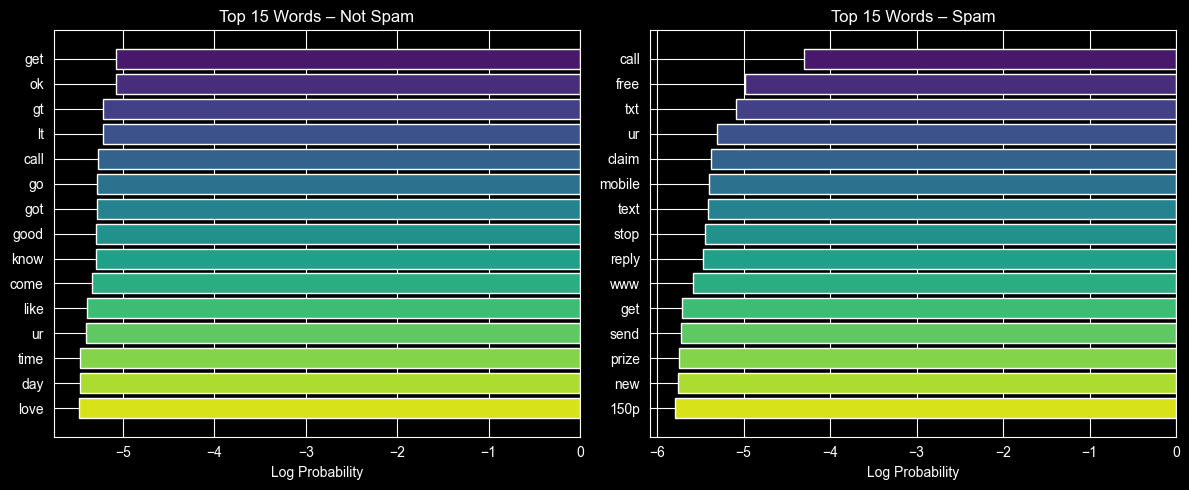

In [10]:
print("Step 6.3: Explainability - Top 15 Words influencing the model")

from src.eval_plots import plot_top_features
fig_feat = plot_top_features(best_model, vectorizer)
plt.show()

# Part 6.4: Data Adaptation

Step 6.4: Class Imbalance Analysis & Data Adaptation

Training Set Class Distribution:
  Not Spam (0): 3873 samples (86.9%)
  Spam (1):     586 samples (13.1%)
  Ratio (Spam / Not Spam): 0.151

The dataset is imbalanced (ratio = 0.151).
   Applying random oversampling to balance the classes.

After Oversampling:
  Not Spam (0): 3873 samples
  Spam (1):     3873 samples
  Total:        7746 samples (was 4459)


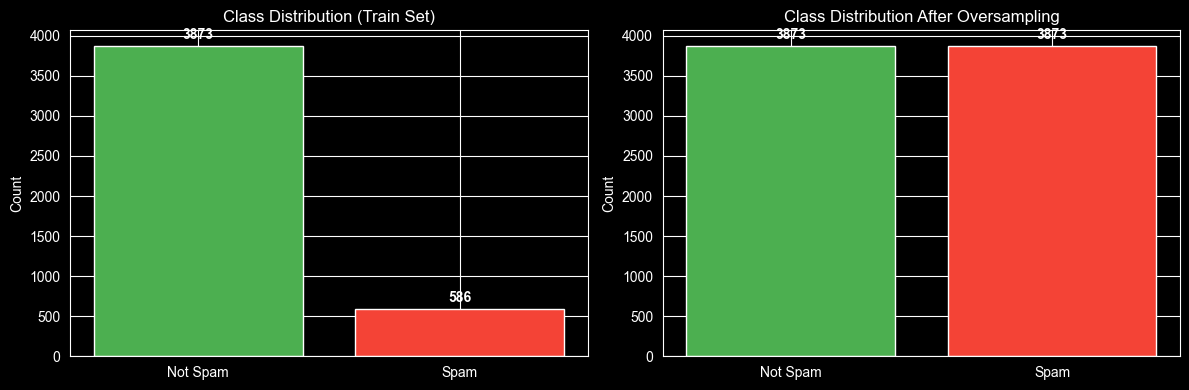


Comparison on Test Set:
  F1 (Original data):     0.9375
  F1 (Oversampled data):  0.8768

Oversampling did not improve performance; the original data was already balanced enough.


In [11]:
import numpy as np
import matplotlib.pyplot as plt

print("Step 6.4: Class Imbalance Analysis & Data Adaptation")

# --- Check class distribution in train set ---
y_train_arr = np.array(y_train)
class_0_count = np.sum(y_train_arr == 0)
class_1_count = np.sum(y_train_arr == 1)
total = len(y_train_arr)
ratio = class_1_count / class_0_count if class_0_count > 0 else 0

print(f"\nTraining Set Class Distribution:")
print(f"  Not Spam (0): {class_0_count} samples ({class_0_count/total*100:.1f}%)")
print(f"  Spam (1):     {class_1_count} samples ({class_1_count/total*100:.1f}%)")
print(f"  Ratio (Spam / Not Spam): {ratio:.3f}")

# --- Visualize the distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['Not Spam', 'Spam']
counts = [class_0_count, class_1_count]
colors = ['#4CAF50', '#F44336']

bars = axes[0].bar(labels, counts, color=colors)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', va='bottom', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Train Set)')

is_balanced = 0.8 <= ratio <= 1.2

if is_balanced:
    print(f"\nhe dataset is relatively balanced (ratio = {ratio:.3f}).")
    print("   No resampling is strictly needed.")
    print("   We will demonstrate random oversampling anyway to show the technique.\n")
else:
    print(f"\nThe dataset is imbalanced (ratio = {ratio:.3f}).")
    print("   Applying random oversampling to balance the classes.\n")

# Find the minority class and oversample it to match the majority
minority_class = 1 if class_1_count < class_0_count else 0
majority_count = max(class_0_count, class_1_count)
minority_count = min(class_0_count, class_1_count)

# Get indices of minority class samples
minority_indices = np.where(y_train_arr == minority_class)[0]

# Randomly sample (with replacement) to fill the gap
np.random.seed(42)
extra_needed = majority_count - minority_count
extra_indices = np.random.choice(minority_indices, size=extra_needed, replace=True)

from scipy import sparse

if sparse.issparse(X_train):
    X_train_oversampled = sparse.vstack([X_train, X_train[extra_indices]])
else:
    X_train_oversampled = np.vstack([X_train, X_train[extra_indices]])

y_train_oversampled = np.concatenate([y_train_arr, y_train_arr[extra_indices]])

new_class_0 = np.sum(y_train_oversampled == 0)
new_class_1 = np.sum(y_train_oversampled == 1)

print(f"After Oversampling:")
print(f"  Not Spam (0): {new_class_0} samples")
print(f"  Spam (1):     {new_class_1} samples")
print(f"  Total:        {len(y_train_oversampled)} samples (was {total})")

# Bar chart after oversampling
bars2 = axes[1].bar(labels, [new_class_0, new_class_1], color=colors)
for bar, count in zip(bars2, [new_class_0, new_class_1]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_title('Class Distribution After Oversampling')

plt.tight_layout()
plt.show()

# --- Train on oversampled data and compare ---
from src.model_logic import CustomMultinomialNB, calculate_metrics

model_original = CustomMultinomialNB(alpha=best_model.alpha, fit_prior=best_model.fit_prior)
model_original.fit(X_train, y_train)
preds_original = model_original.predict(X_test)
_, _, _, f1_original = calculate_metrics(y_test, preds_original)

model_oversampled = CustomMultinomialNB(alpha=best_model.alpha, fit_prior=best_model.fit_prior)
model_oversampled.fit(X_train_oversampled, y_train_oversampled)
preds_oversampled = model_oversampled.predict(X_test)
_, _, _, f1_oversampled = calculate_metrics(y_test, preds_oversampled)

print(f"\nComparison on Test Set:")
print(f"  F1 (Original data):     {f1_original:.4f}")
print(f"  F1 (Oversampled data):  {f1_oversampled:.4f}")

if abs(f1_original - f1_oversampled) < 0.01:
    print("\nResults are very similar, confirming the dataset was already well-balanced.")
elif f1_oversampled > f1_original:
    print("\nOversampling improved the F1 score.")
else:
    print("\nOversampling did not improve performance; the original data was already balanced enough.")



# Part 6.5: Special Quality Metric


Step 6.5: AUC-ROC Calculation
Sample probabilities (first 5):
  Sample 0: P(Spam) = 0.0002, Actual = Not Spam
  Sample 1: P(Spam) = 0.0000, Actual = Not Spam
  Sample 2: P(Spam) = 0.0071, Actual = Not Spam
  Sample 3: P(Spam) = 0.0000, Actual = Not Spam
  Sample 4: P(Spam) = 0.0084, Actual = Not Spam

*** AUC-ROC Score: 0.9861 ***
Excellent: The model has outstanding discrimination ability.


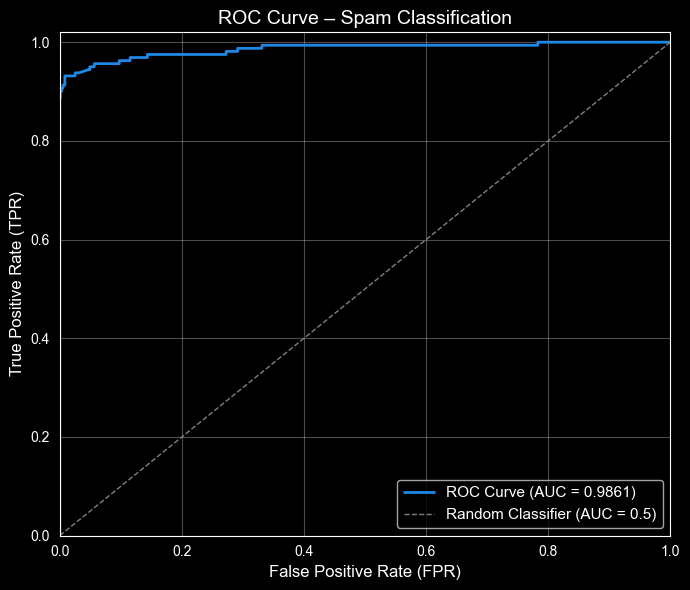

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

print("Step 6.5: AUC-ROC Calculation")

# We compute probabilities from the log-probabilities using softmax
def predict_proba(model, X):
    jll = X.dot(model.feature_log_prob_.T) + model.class_log_prior_
    jll_array = np.array(jll)
    max_jll = np.max(jll_array, axis=1, keepdims=True)
    exp_jll = np.exp(jll_array - max_jll)
    probabilities = exp_jll / np.sum(exp_jll, axis=1, keepdims=True)

    return probabilities

# Get probability of the positive class (Spam = class 1)
probas = predict_proba(best_model, X_test)
spam_probas = probas[:, 1]  # probability of being Spam

print(f"Sample probabilities (first 5):")
for i in range(5):
    print(f"  Sample {i}: P(Spam) = {spam_probas[i]:.4f}, Actual = {'Spam' if y_test.iloc[i] == 1 else 'Not Spam'}")

fpr, tpr, _ = roc_curve(y_test, spam_probas)
roc_auc = auc(fpr, tpr)

print(f"\n*** AUC-ROC Score: {roc_auc:.4f} ***")

if roc_auc >= 0.9:
    print("Excellent: The model has outstanding discrimination ability.")
elif roc_auc >= 0.8:
    print("Good: The model has strong discrimination ability.")
elif roc_auc >= 0.7:
    print("Fair: The model has acceptable discrimination ability.")
else:
    print("Poor: The model struggles to distinguish between classes.")

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='#1E88E5', linewidth=2,
        label=f'ROC Curve (AUC = {roc_auc:.4f})')

# Random classifier baseline
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1,
        label='Random Classifier (AUC = 0.5)')

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12)
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12)
ax.set_title('ROC Curve – Spam Classification', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()